<h3 style="text-align: center; background-color: #5AA647; color: white; padding: 8px; border-radius: 6px;">
ANN - Artificial Neural Network
</h3>

##### Importing Libraries

In [1]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

#Evaluation library
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# Deep Learning libraries
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier

#### Loading the Dataset

In [2]:
#Digit MNIST dataset
(X_train_digit, y_train_digit), (X_test_digit, y_test_digit) = mnist.load_data()

In [3]:
X_train_digit[1] ## Printing the value stored at index  position 1

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [4]:
y_train_digit ## Contains actual output (Labels)

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

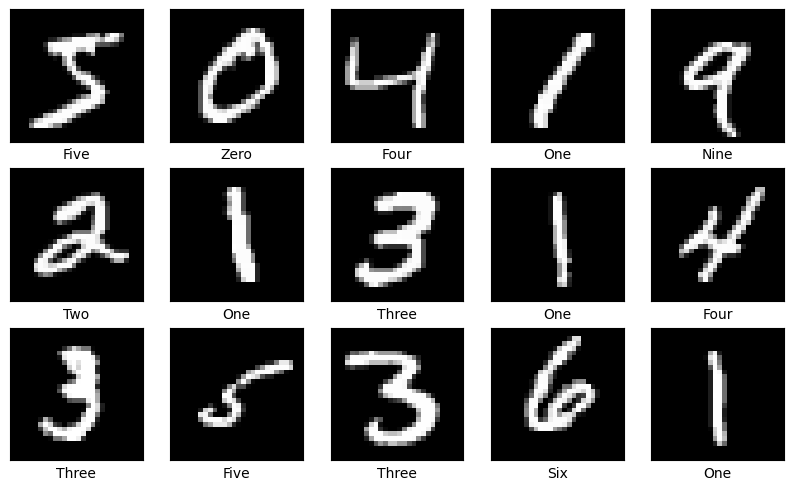

In [5]:
# Names for digits 0–9
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

# Create figure for plotting images
plt.figure(figsize=(10,10))

# Loop through first 15 images
for i in range(15):
    plt.subplot(5,5,i+1)           # Create grid (5x5)
    plt.xticks([])                # Remove x-axis ticks
    plt.yticks([])                # Remove y-axis ticks
    plt.imshow(X_train_digit[i], cmap='gray')   # Show image
    plt.xlabel(col_names[y_train_digit[i]])     # Show label name

plt.show()# Display all images

In [6]:
X_train_digit.shape ## Shape of the training data 60000 - Images, 28 rows and 28 columns

(60000, 28, 28)

#### ANN requires input to be in 2D format (samples × features), so we reshape the data

In [7]:
X_train_digit = X_train_digit.reshape(60000, 784)
X_test_digit = X_test_digit.reshape(10000, 784)

In [8]:
X_train_digit.shape ## Converted 2D shape

(60000, 784)

In [9]:
y_test_digit.shape # Contains 10,000 output labels for test data

(10000,)

In [10]:
#Encoding Digit MNIST Labels
# Convert training labels into one-hot encoded format (10 classes)
y_train_digit = to_categorical(y_train_digit, num_classes=10)

# Convert test labels into one-hot encoded format (10 classes)
y_test_digit = to_categorical(y_test_digit, num_classes=10)

In [11]:
y_train_digit[1]  # One-hot encoded label of the second image

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [12]:
# Creating a basic Artificial Neural Network (ANN) model
model = keras.Sequential([

    layers.Dense(256, activation='relu', input_shape=(784,)),  # Input layer: 784 features → 256 neurons

    layers.Dropout(0.3),         # (Optional) Prevent overfitting
    layers.BatchNormalization(), # (Optional) Normalize outputs

    layers.Dense(64, activation='relu'),   # Hidden layer: 64 neurons

    layers.Dropout(0.3),
    layers.BatchNormalization(),

    layers.Dense(64, activation='relu'),   # Hidden layer: 64 neurons

    #layers.Dropout(0.3),
    #layers.BatchNormalization(),

    layers.Dense(10, activation='sigmoid'), # Output layer: 10 neurons (digits 0–9)
])

C:\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
#param_number = output_channel_number * (input_channel_number + 1)
model.summary() ## shows how many weights (parameters) your ANN is learning

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 223,498 (873.04 KB)

 Trainable params: 222,858 (870.54 KB)

 Non-trainable params: 640 (2.50 KB)

In [14]:
#Compiling the model

model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics = ['accuracy'])

In [15]:
# Train the ANN using training data and validate using test data
##Total training data = 60,000 images
## Batch size = 100
## 60000 ÷ 100 = 600 batches
## epochs = 10 The model will go through the entire dataset 10 times (forward Feedback and Backward Propagation)
history=model.fit(X_train_digit, y_train_digit, batch_size=100, epochs=10,validation_data=(X_test_digit, y_test_digit))

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8767 - loss: 0.4106 - val_accuracy: 0.9577 - val_loss: 0.1367
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9418 - loss: 0.1977 - val_accuracy: 0.9650 - val_loss: 0.1135
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9527 - loss: 0.1579 - val_accuracy: 0.9714 - val_loss: 0.0938
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9583 - loss: 0.1363 - val_accuracy: 0.9723 - val_loss: 0.0947
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9623 - loss: 0.1231 - val_accuracy: 0.9726 - val_loss: 0.0911
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9667 - loss: 0.1105 - val_accuracy: 0.9742 - val_loss: 0.0898
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9676 - loss: 0.1048 - val_accuracy: 0.9768 - val_loss: 0.0794
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9703 - loss: 0.0975 - val_accuracy: 0.

In [16]:
#Predicting the labels-DIGIT
y_predict = model.predict(X_test_digit)  # Predicts output probabilities for test data

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [17]:
y_predict[0]  # Predicted probabilities for the first test image

array([2.4188396e-02, 2.7168456e-01, 4.2986220e-01, 5.7446814e-01,
       4.0590238e-02, 5.6902084e-02, 2.8261924e-04, 9.9996954e-01,
       2.8798407e-02, 7.6893330e-01], dtype=float32)

In [18]:
 # Converts probability vectors into predicted digit labels by selecting the index of the highest value
y_predicts = np.argmax(y_predict, axis=1) 

In [19]:
y_predicts  # Predicted digit labels for all test images

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [20]:
# Converts one-hot encoded test labels back to original digit values
y_test_digit_eval = np.argmax(y_test_digit, axis=1)  

In [21]:
y_test_digit_eval  # Actual digit labels (0–9) for all test images

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

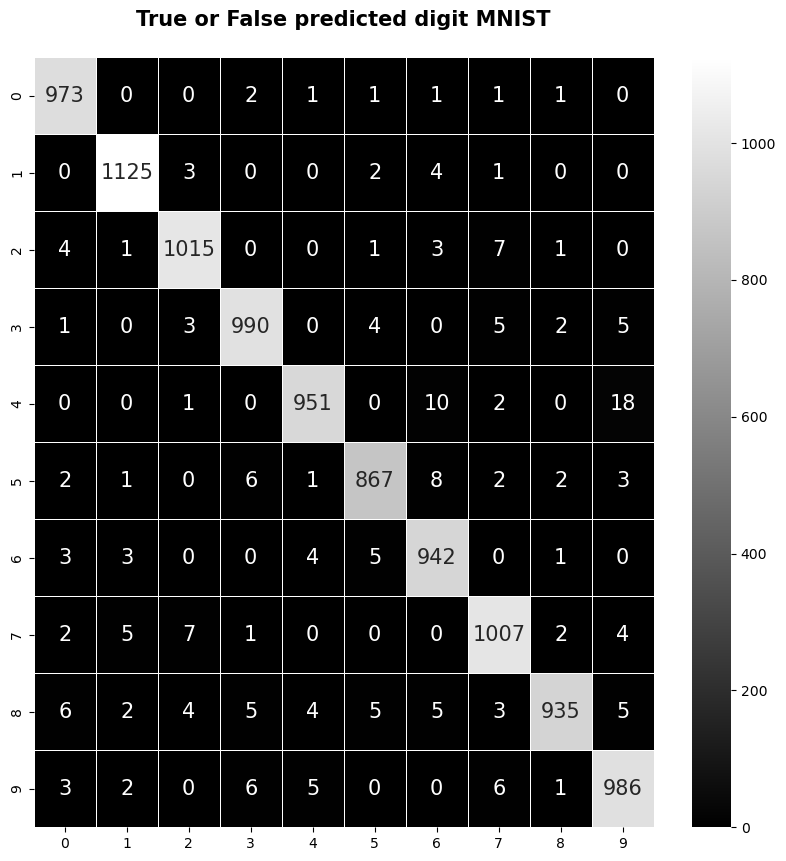

In [22]:
# Create confusion matrix comparing actual vs predicted labels
con_mat = confusion_matrix(y_test_digit_eval, y_predicts)

# Set plot style
plt.style.use('seaborn-v0_8-deep')

# Create figure
plt.figure(figsize=(10,10))

# Plot confusion matrix as heatmap
sns.heatmap(con_mat, annot=True, annot_kws={'size': 15}, 
            linewidths=0.5, fmt="d", cmap="gray")

# Add title
plt.title('True or False predicted digit MNIST\n',
          fontweight='bold', fontsize=15)

# Display plot
plt.show()

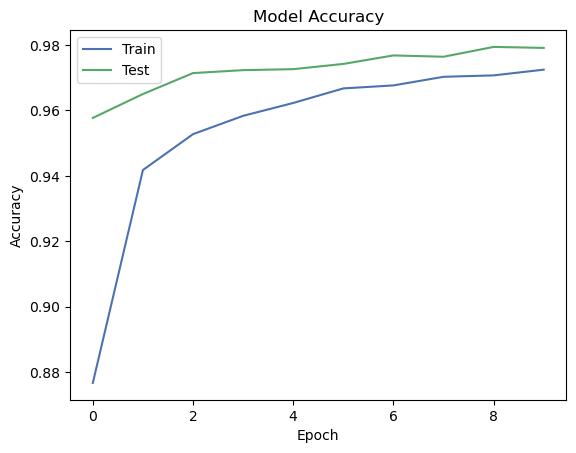

In [23]:
# Plot training and validation accuracy over epochs
plt.plot(history.history['accuracy'])       # Training accuracy
plt.plot(history.history['val_accuracy'])   # Validation (test) accuracy

# Set plot title and labels
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

# Add legend to differentiate lines
plt.legend(['Train', 'Test'], loc='best')

# Display the plot
plt.show()

In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test_digit_eval,y_predicts))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.97      0.98       982
           5       0.98      0.97      0.98       892
           6       0.97      0.98      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.99      0.96      0.97       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



#### Test for Single image in Index 2

In [25]:
# Predict output for a single test image (index 2)
y_predict_single = model.predict(X_test_digit[[2]])

# Convert predicted probabilities to actual digit prediction
y_predicts_single = np.argmax(y_predict_single, axis=1)

# Convert one-hot encoded test labels back to original digits
y_test_digit_eval = np.argmax(y_test_digit, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


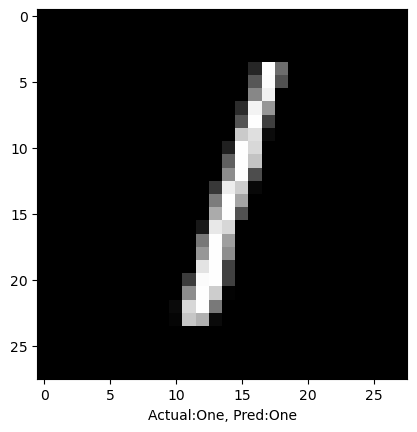

In [26]:
# Names for digits (0–9)
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

# Display the 3rd test image (index 2)
plt.imshow(X_test_digit[2].reshape(28,28), cmap='gray')  # Reshape to image form

# Show actual vs predicted label
plt.xlabel("Actual:{}, Pred:{}".format(
    col_names[np.argmax(y_test_digit[2])],   # Actual digit
    col_names[y_predicts_single[0]]          # Predicted digit
))

plt.show()  # Display image

#### Before adding Dropout and Normalization (For Reference only)

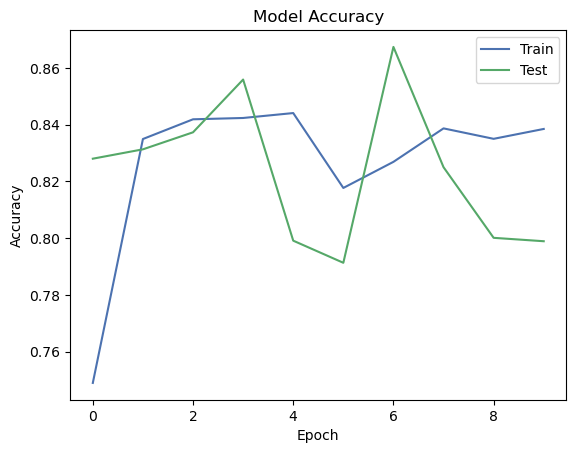

In [34]:
# Plot training and validation accuracy over epochs
plt.plot(history.history['accuracy'])       # Training accuracy
plt.plot(history.history['val_accuracy'])   # Validation (test) accuracy

# Set plot title and labels
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

# Add legend to differentiate lines
plt.legend(['Train', 'Test'], loc='best')

# Display the plot
plt.show()

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test_digit_eval,y_predicts))

              precision    recall  f1-score   support

           0       0.64      0.99      0.78       980
           1       0.76      0.99      0.86      1135
           2       0.83      0.67      0.74      1032
           3       0.65      0.96      0.77      1010
           4       0.94      0.98      0.96       982
           5       0.71      0.36      0.48       892
           6       0.93      0.35      0.51       958
           7       0.96      0.87      0.91      1028
           8       0.95      0.95      0.95       974
           9       0.98      0.93      0.95      1009

    accuracy                           0.81     10000
   macro avg       0.84      0.80      0.79     10000
weighted avg       0.84      0.81      0.80     10000

